In [9]:
import pandas as pd
import numpy as np
import xgboost as xgb

In [10]:
df = pd.read_csv("../dataset/2023-2025_dataset.csv", sep=";")

In [11]:
df["solar_projection"] = df["lw_germany_solar_gen"] * (df["solar_baseload"] / df["lw_solar_baseload"])

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

df[numeric_cols] = df[numeric_cols].bfill().ffill()

categorical_features = ['is_peak', 'period']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype(int).astype('category')

In [13]:
features_to_remove = [
    'price',
    'germany_nuclear_gen_last_week', 
    'germany_lignite_gen_last_week',
    'germany_other_gen_last_week',
    'czechia_other_gen_last_week',
    'czechia_hard_coal_gen_last_week',
    'czechia_nuclear_gen_last_week',
    'germany_hydro_passive_gen_last_week',
    'czechia_hydro_passive_gen_last_week',
    'czechia_biomass_gen_last_week',
    'germany_biomass_gen_last_week',
    'germany_hard_coal_gen_last_week',
    'czechia_fossil_gas_gen_last_week',
    'germany_fossil_gas_gen_last_week',
    'czechia_lignite_gen_last_week',
    'solar_baseload', 'solar_peakload', 'solar_offpeak', 'lw_solar_offpeak', 'lw_solar_baseload', 'lw_solar_peakload',
]

X = df.drop(columns=features_to_remove)
y = df['price']

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [15]:
tscv = TimeSeriesSplit(n_splits=5, gap=96)

params = {
    'objective': 'reg:absoluteerror',
    'learning_rate': 0.05,     # Slow and steady learning
    'max_depth': 6,            # Enough to catch complex DE/CZ interactions
    'subsample': 0.9,          # Use 90% of data to prevent overfitting
    'colsample_bytree': 0.8,   # Use 80% of features per tree
    'min_child_weight': 50,
    'reg_lambda': 10,
    'eval_metric': 'mae'       # Mean Absolute Error is best for prices
}

# Initialize a list to save scores from each loop
mae_scores = []

for train_index, test_index in tscv.split(X):
    # 1. Split Data
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # 2. Create Matrices (INSIDE LOOP)
    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

    # 3. Train Model (INSIDE LOOP)
    # This creates a NEW model for this specific time slice
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dtest, 'eval')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    # 4. Save Results (INSIDE LOOP)
    # If you don't save it here, it gets overwritten in the next loop!
    prediction = model.predict(dtest)
    score = mean_absolute_error(y_test, prediction)
    mae_scores.append(score)
    
    print(f"Fold MAE: {score}")

# Now you can exit the loop and calculate the average
print(f"Final Average MAE: {np.mean(mae_scores)}")

Fold MAE: 12.849978769909113
Fold MAE: 10.576980508181872
Fold MAE: 16.58867971627223
Fold MAE: 13.234770874164655
Fold MAE: 12.671925051975967
Final Average MAE: 13.184466984100766


In [16]:
import matplotlib.pyplot as plt
importance = model.get_score(importance_type='gain')

# 2. Převedení na Pandas DataFrame pro snadnou manipulaci
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

# 3. Vykreslení velkého grafu pro VŠECHNY featury
plt.figure(figsize=(10, 20)) # Hodně vysoký graf, aby se tam vše vešlo
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance (Total Gain)')
plt.title('Kompletní žebříček důležitosti všech prvků')
plt.gca().invert_yaxis() # Nejdůležitější nahoře
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

/tmp/ipykernel_33285/510811382.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_period = results_df.groupby('period')['abs_error'].mean()


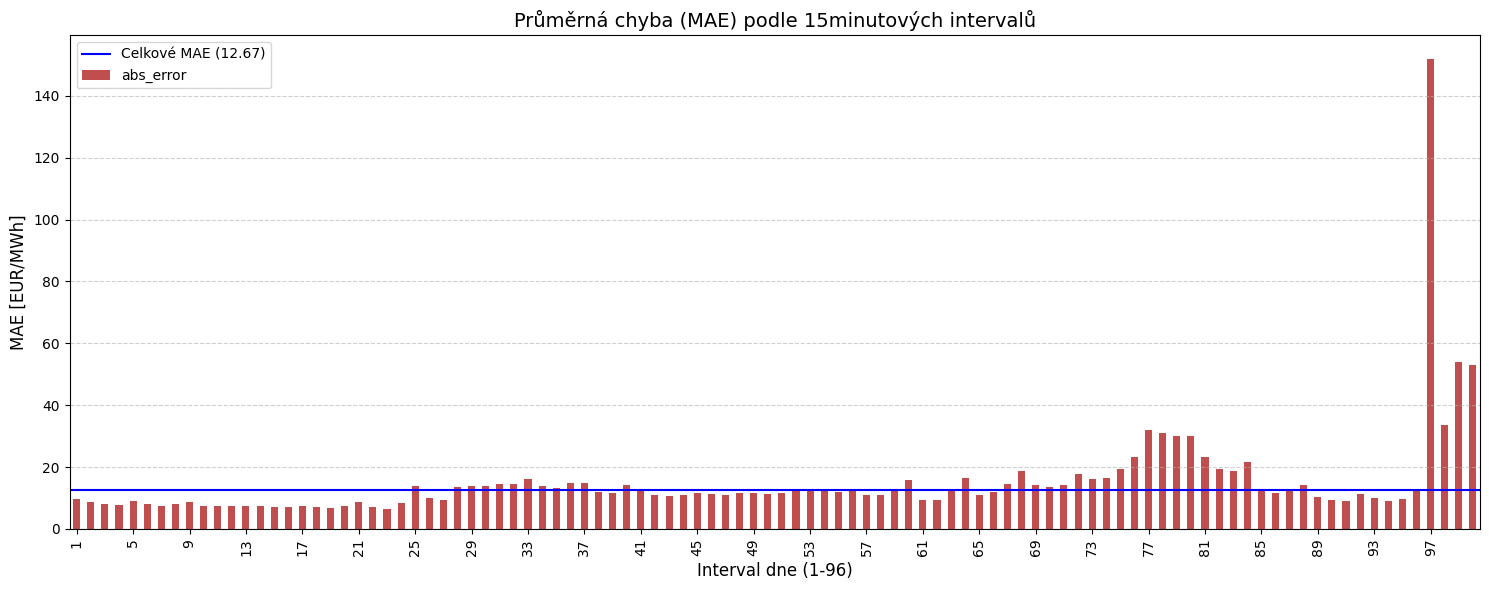

In [610]:
# 1. Výpočet absolutní chyby pro každý řádek v testovacím setu
# Předpokládáme, že y_test a y_pred jsou zarovnané a X_test obsahuje sloupec 'period'
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['prediction'] = model.predict(dtest)
results_df['abs_error'] = np.abs(results_df['actual'] - results_df['prediction'])

# 2. Seskupení podle 15minutového intervalu a výpočet průměrné chyby (MAE)
mae_per_period = results_df.groupby('period')['abs_error'].mean()

# 3. Vykreslení grafu
plt.figure(figsize=(15, 6))
mae_per_period.plot(kind='bar', color='firebrick', alpha=0.8)

plt.title('Průměrná chyba (MAE) podle 15minutových intervalů', fontsize=14)
plt.xlabel('Interval dne (1-96)', fontsize=12)
plt.ylabel('MAE [EUR/MWh]', fontsize=12)
plt.xticks(np.arange(0, 97, 4)) # Zobrazení každé hodiny (4 * 15 min)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Přidání linky pro celkové průměrné MAE pro srovnání
plt.axhline(y=results_df['abs_error'].mean(), color='blue', linestyle='-', label=f"Celkové MAE ({results_df['abs_error'].mean():.2f})")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_33285/955680548.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_period = results_standard.groupby('period')['abs_error'].mean()


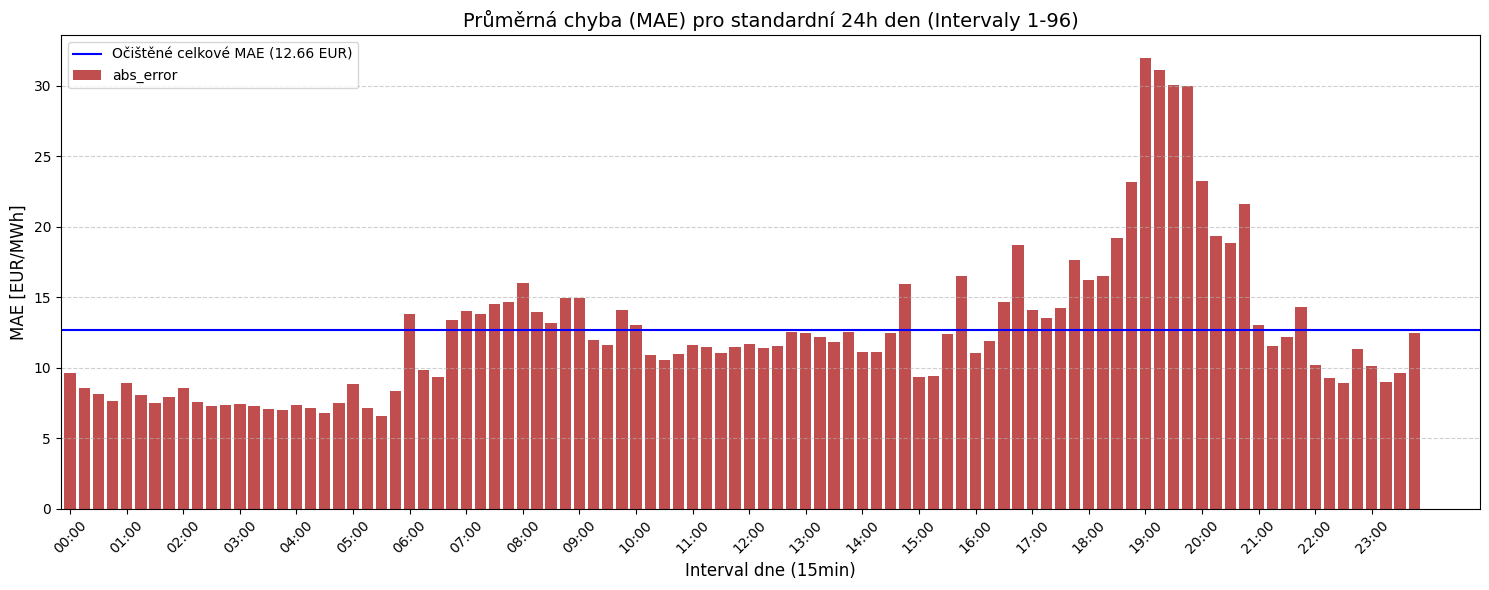

Původní MAE (včetně DST): 12.6690
Nové MAE (pouze standardní dny): 12.6552


In [611]:
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['prediction'] = model.predict(dtest)
results_df['abs_error'] = np.abs(results_df['actual'] - results_df['prediction'])

# 2. FILTRACE: Ponecháme pouze standardní 15minutové intervaly (1-96)
results_standard = results_df[results_df['period'].astype(int) <= 96]

# 3. Seskupení a výpočet MAE pro standardní den
mae_per_period = results_standard.groupby('period')['abs_error'].mean()
overall_mae_standard = results_standard['abs_error'].mean()

# 4. Vykreslení grafu
plt.figure(figsize=(15, 6))
mae_per_period.plot(kind='bar', color='firebrick', alpha=0.8, width=0.8)

plt.title('Průměrná chyba (MAE) pro standardní 24h den (Intervaly 1-96)', fontsize=14)
plt.xlabel('Interval dne (15min)', fontsize=12)
plt.ylabel('MAE [EUR/MWh]', fontsize=12)

# Nastavení osy X: popisky každou celou hodinu (každý 4. interval)
plt.xticks(np.arange(0, 96, 4), labels=[f"{h:02d}:00" for h in range(24)], rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Přidání linky pro celkové MAE (očištěné o DST pík)
plt.axhline(y=overall_mae_standard, color='blue', linestyle='-', 
            label=f"Očištěné celkové MAE ({overall_mae_standard:.2f} EUR)")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Původní MAE (včetně DST): {results_df['abs_error'].mean():.4f}")
print(f"Nové MAE (pouze standardní dny): {overall_mae_standard:.4f}")

/tmp/ipykernel_33285/3030451880.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_per_period = results_standard.groupby('period')['error'].mean()


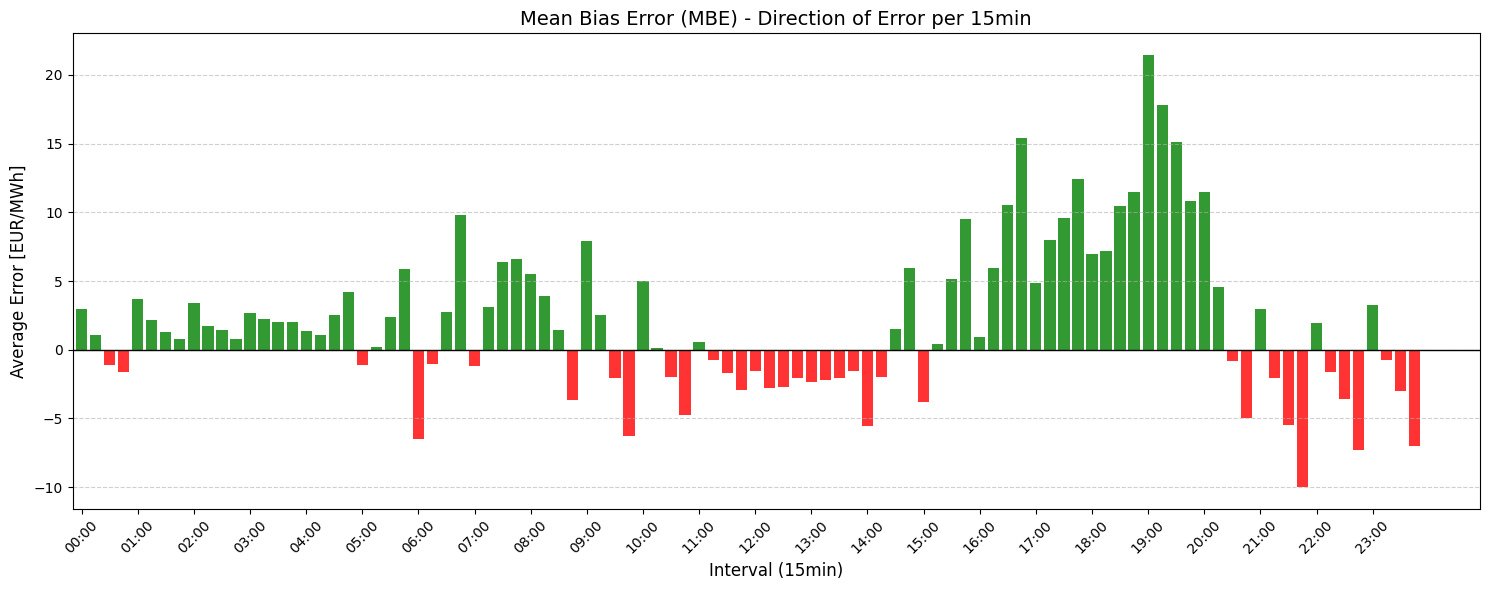

Average Bias between 18:00-21:00: 9.54 EUR
CONCLUSION: You are UNDER-predicting (Model is too cheap).


In [612]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate Signed Error (No np.abs)
# Positive = Underprediction (Price was higher than model thought)
# Negative = Overprediction (Price was lower than model thought)
results_df['error'] = results_df['actual'] - results_df['prediction']

# 2. FILTRACE: Standard intervals only
results_standard = results_df[results_df['period'].astype(int) <= 96]

# 3. Calculate Mean Bias per period
bias_per_period = results_standard.groupby('period')['error'].mean()

# 4. Visualization
plt.figure(figsize=(15, 6))

# Create conditional colors: Red for Overprediction (Negative), Green for Underprediction (Positive)
# You can swap colors based on your preference
colors = ['red' if x < 0 else 'green' for x in bias_per_period]

bias_per_period.plot(kind='bar', color=colors, alpha=0.8, width=0.8)

plt.title('Mean Bias Error (MBE) - Direction of Error per 15min', fontsize=14)
plt.xlabel('Interval (15min)', fontsize=12)
plt.ylabel('Average Error [EUR/MWh]', fontsize=12)

# Add a zero line so you can clearly see the baseline
plt.axhline(0, color='black', linewidth=1)

# X-Axis formatting (Every hour)
plt.xticks(np.arange(0, 96, 4), labels=[f"{h:02d}:00" for h in range(24)], rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Quick Diagnosis Print
evening_bias = bias_per_period.loc[72:84].mean()
print(f"Average Bias between 18:00-21:00: {evening_bias:.2f} EUR")
if evening_bias > 0:
    print("CONCLUSION: You are UNDER-predicting (Model is too cheap).")
else:
    print("CONCLUSION: You are OVER-predicting (Model is too expensive).")

/tmp/ipykernel_33285/2389176892.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_per_period = results_standard.groupby('period')['abs_error'].median()


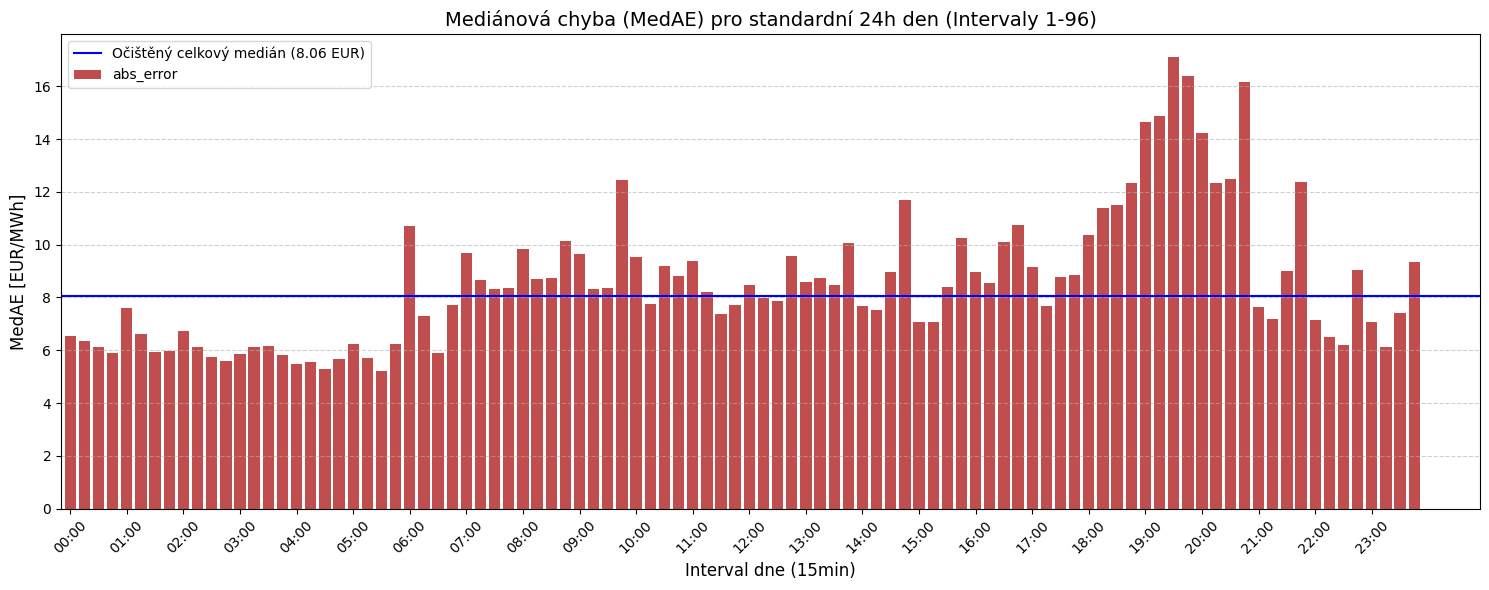

Původní medián chyby (včetně DST): 8.0670
Nový medián chyby (pouze standardní dny): 8.0618


In [613]:
results_df = X_test.copy()
results_df['actual'] = y_test
results_df['prediction'] = model.predict(dtest)
results_df['abs_error'] = np.abs(results_df['actual'] - results_df['prediction'])

# 2. FILTRACE: Ponecháme pouze standardní 15minutové intervaly (1-96)
results_standard = results_df[results_df['period'].astype(int) <= 96]

# 3. Seskupení a výpočet mediánu pro standardní den
# Změna z .mean() na .median()
median_per_period = results_standard.groupby('period')['abs_error'].median()
overall_median_standard = results_standard['abs_error'].median()

# 4. Vykreslení grafu
plt.figure(figsize=(15, 6))
median_per_period.plot(kind='bar', color='firebrick', alpha=0.8, width=0.8)

plt.title('Mediánová chyba (MedAE) pro standardní 24h den (Intervaly 1-96)', fontsize=14)
plt.xlabel('Interval dne (15min)', fontsize=12)
plt.ylabel('MedAE [EUR/MWh]', fontsize=12)

# Nastavení osy X: popisky každou celou hodinu (každý 4. interval)
plt.xticks(np.arange(0, 96, 4), labels=[f"{h:02d}:00" for h in range(24)], rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Přidání linky pro celkový medián
plt.axhline(y=overall_median_standard, color='blue', linestyle='-', 
            label=f"Očištěný celkový medián ({overall_median_standard:.2f} EUR)")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Původní medián chyby (včetně DST): {results_df['abs_error'].median():.4f}")
print(f"Nový medián chyby (pouze standardní dny): {overall_median_standard:.4f}")

/tmp/ipykernel_33285/3563988640.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_err_per_period = results_standard.groupby('period')['abs_error'].median()
/tmp/ipykernel_33285/3563988640.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_per_period = results_standard.groupby('period')['actual'].mean()


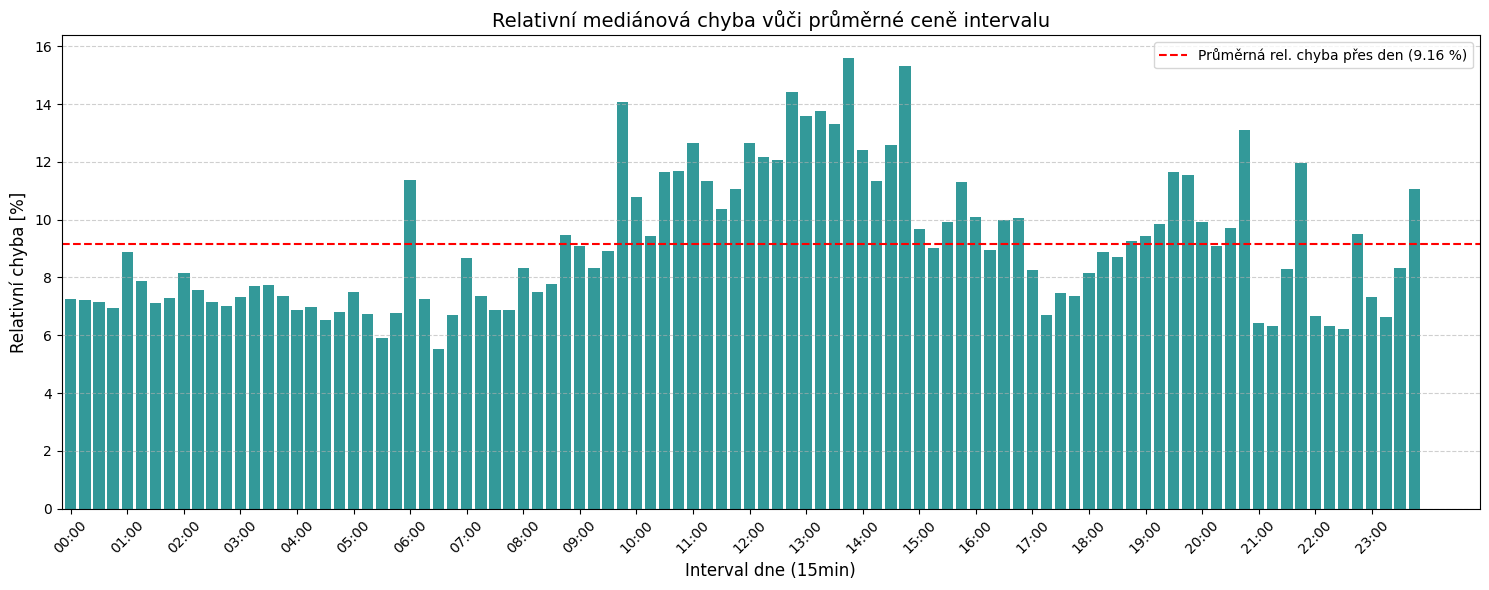

--- DETAILNÍ ANALÝZA PODLE INTERVALŮ ---
Interval s nejnižší rel. chybou: 27 (5.53 %)
Interval s nejvyšší rel. chybou: 56 (15.60 %)
Průměrná relativní chyba napříč dnem: 9.16 %


In [614]:
# 1. Výpočet metrik pro každý interval (1-96)
# Mediánová chyba pro každý interval
median_err_per_period = results_standard.groupby('period')['abs_error'].median()

# Průměrná skutečná cena pro každý interval
avg_price_per_period = results_standard.groupby('period')['actual'].mean()

# 2. Výpočet relativní chyby v procentech pro každý interval
# (Jak velkou část průměrné ceny daného intervalu tvoří typická chyba)
relative_error_per_period = (median_err_per_period / avg_price_per_period) * 100

# 3. Vykreslení grafu relativní chyby
plt.figure(figsize=(15, 6))
relative_error_per_period.plot(kind='bar', color='teal', alpha=0.8, width=0.8)

plt.title('Relativní mediánová chyba vůči průměrné ceně intervalu', fontsize=14)
plt.xlabel('Interval dne (15min)', fontsize=12)
plt.ylabel('Relativní chyba [%]', fontsize=12)

# Nastavení osy X: popisky každou celou hodinu
plt.xticks(np.arange(0, 96, 4), labels=[f"{h:02d}:00" for h in range(24)], rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)

# Přidání linky pro celkový průměr relativních chyb
overall_rel_error = relative_error_per_period.mean()
plt.axhline(y=overall_rel_error, color='red', linestyle='--', 
            label=f"Průměrná rel. chyba přes den ({overall_rel_error:.2f} %)")

plt.legend()
plt.tight_layout()
plt.show()

# Výpis statistik do konzole
print(f"--- DETAILNÍ ANALÝZA PODLE INTERVALŮ ---")
print(f"Interval s nejnižší rel. chybou: {relative_error_per_period.idxmin()} ({relative_error_per_period.min():.2f} %)")
print(f"Interval s nejvyšší rel. chybou: {relative_error_per_period.idxmax()} ({relative_error_per_period.max():.2f} %)")
print(f"Průměrná relativní chyba napříč dnem: {overall_rel_error:.2f} %")